# Lab 5: Visualizing Vector Search

In this lab students will **see how vector search works** by visualizing embeddings.

What you will learn:

1. Convert text into embeddings
2. Reduce embedding dimensions using PCA
3. Visualize vectors in 2D space
4. Understand how similarity search works

This helps students understand what happens inside a **vector database used in RAG systems**.

# Step 1 — Install Libraries

In [1]:
!pip install sentence-transformers scikit-learn matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:


from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

c:\Projects\PVS1\Project1-PVS\Project1-PVS\rag-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


# Step 2 — Import Libraries

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 3 — Example Documents

These sentences simulate chunks from documents.

In [4]:
documents = [
    'Cats are small domesticated animals.',
    'Dogs are loyal pets commonly kept by humans.',
    'Tigers are wild animals found in forests.',
    'Lions are powerful predators.',
    'Apples and bananas are fruits.',
    'Oranges are citrus fruits.',
    'Strawberries are sweet fruits.',
    'Cars and trucks are vehicles.',
    'Airplanes fly in the sky.',
    'Ships travel across oceans.'
]

# Step 4 — Load Embedding Model

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

#we can see that it is a dense vector of 384 dimensions
# it is downloaded at -C:\Users\hetarra\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2

c:\Projects\PVS1\Project1-PVS\Project1-PVS\rag-env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hetarra\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6498.79it/s]
BertMode

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load embedding model (downloads once, then cached locally)
#mdel = SentenceTransformer("all-MiniLM-L6-v2")

# Input sentences
sentence1 = "Hyderabad has best biryani"
sentence2 = "Best Biryani is found in Hyderabad"

# Convert to embeddings (vectors)
embedding1 = model.encode(sentence1)
embedding2 = model.encode(sentence2)

# Compute cosine similarity
similarity = cosine_similarity([embedding1], [embedding2])[0][0]

print("\n🔍 Cosine Similarity:", similarity)


🔍 Cosine Similarity: 0.9173976


# Step 5 — Convert Text to Embeddings

In [10]:
embeddings = model.encode(documents)

print('Embedding shape:', embeddings.shape)

print('First embedding vector:', embeddings[0])

Embedding shape: (10, 384)
First embedding vector: [ 1.39778376e-01  6.71734512e-02  2.15401575e-02  6.29254207e-02
 -7.58162662e-02 -7.90167227e-03 -5.17022945e-02 -4.28220592e-02
 -2.80856788e-02  4.31599803e-02  3.58969159e-02 -6.28652647e-02
 -3.74917947e-02  1.85419084e-03 -9.28460900e-03 -3.26215588e-02
 -6.53998479e-02 -1.44956410e-02 -8.02441221e-03  8.41045231e-02
 -9.23095867e-02  1.10467905e-02 -1.70786176e-02  1.46931959e-02
 -7.12446868e-03  4.53148596e-02 -5.76880910e-02 -3.53428014e-02
 -2.55323909e-02  1.14397807e-02 -3.64393406e-02  2.68512778e-02
  5.17742857e-02  3.54195945e-02 -3.17061283e-02 -3.36476490e-02
  3.10893524e-02  5.28609417e-02  5.84637113e-02  4.27503698e-02
  1.10957157e-02 -7.10620359e-02  3.32094207e-02 -1.85724627e-02
 -3.14055756e-02  4.16913964e-02  2.64068507e-03 -7.46291801e-02
 -8.33795872e-03 -7.81672820e-02 -4.15356345e-02  6.81584850e-02
 -6.04406036e-02  1.95751693e-02  1.98035641e-03 -7.69833252e-02
  8.91198032e-03 -6.35515079e-02  8.450

# Step 6 — Reduce Dimensions to 2D

Embeddings are usually **384 or 768 dimensions**.

We reduce them to **2 dimensions** so we can visualize them.

In [7]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(embeddings)

# Step 7 — Plot the Embeddings

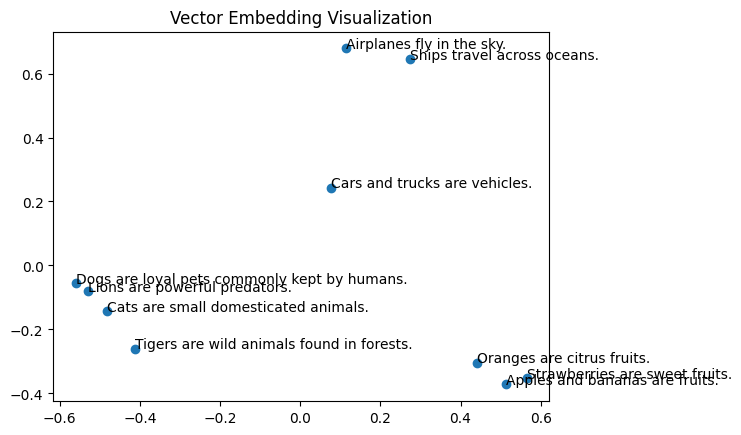

In [8]:
plt.figure()
x = reduced_vectors[:,0]
y = reduced_vectors[:,1]

plt.scatter(x, y)

for i, txt in enumerate(documents):
    plt.annotate(txt, (x[i], y[i]))

plt.title('Vector Embedding Visualization')
plt.show()

# Step 8 — Vector Similarity Search

Let's ask a question and find the most similar sentence.

In [9]:
query = 'Which animals live in forests?'

query_embedding = model.encode([query])[0]

from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity([query_embedding], embeddings)[0]

best_match_index = np.argmax(scores)

print('Query:', query)
print('Best matching document:', documents[best_match_index])

Query: Which animals live in forests?
Best matching document: Tigers are wild animals found in forests.


# What Just Happened?

1. Each sentence was converted into a vector.
2. Similar sentences are placed closer together in vector space.
3. The query was also converted into a vector.
4. We measured similarity using **cosine similarity**.

This is exactly how **vector databases retrieve relevant chunks in RAG systems**.